# Figure 6D: GO enrichment bubble plot

Run cells from top to bottom. Paths and thread counts are centralized in `config/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
input_file <- legacy_path("20250611-p38-draw/pathway/4CD115+CDP.xlsx")

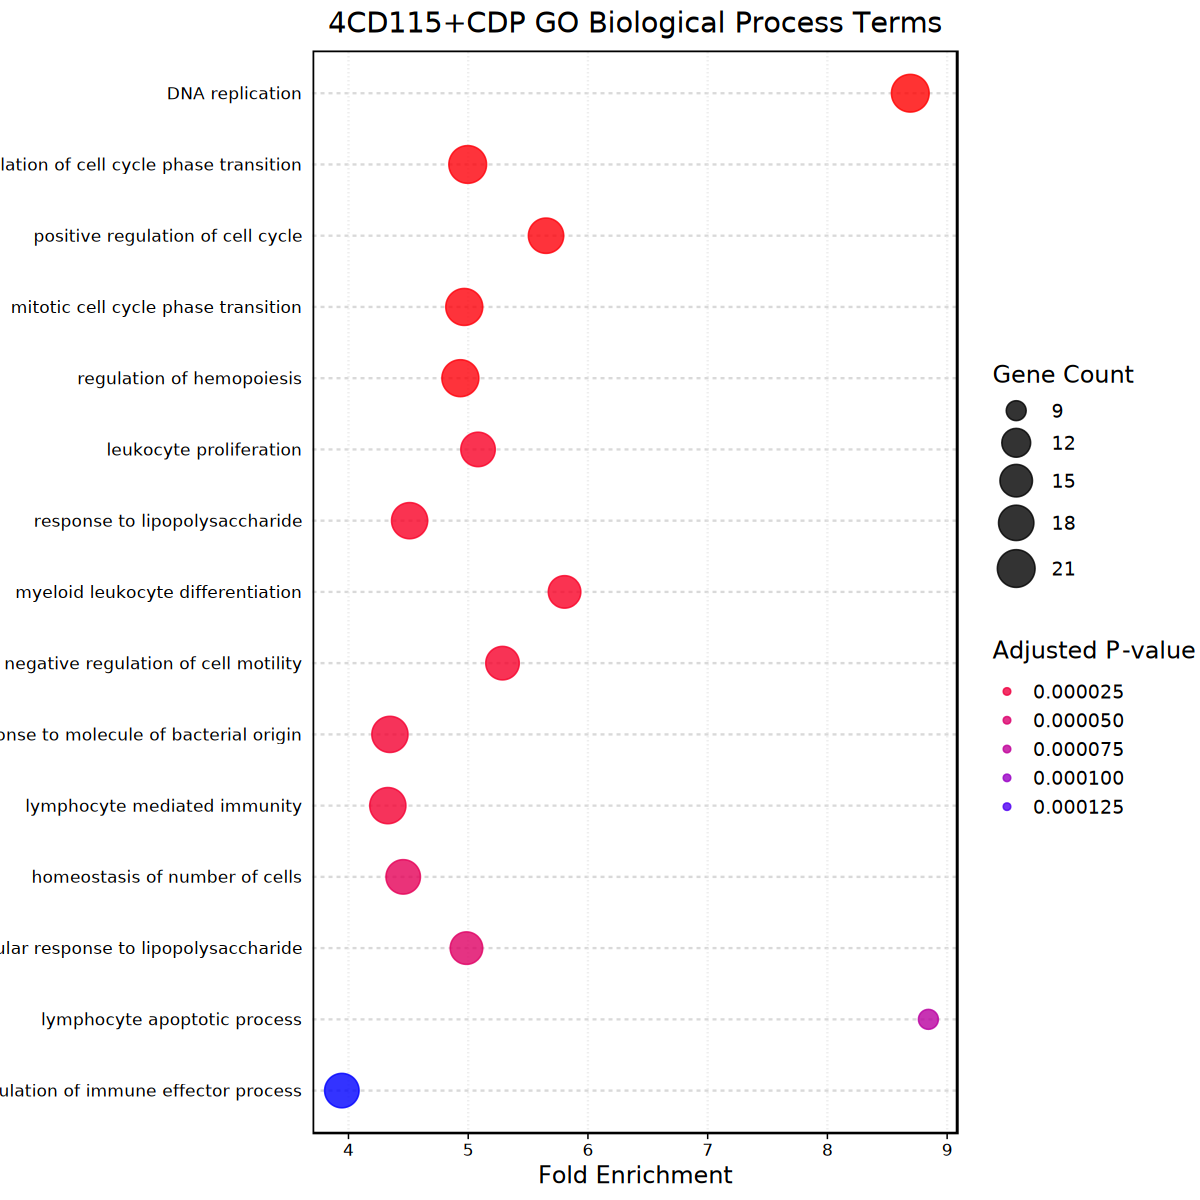

In [2]:
suppressPackageStartupMessages({ 
    library(readxl) # !!! 修改：使用 readxl 读取 Excel 文件
    library(dplyr)
    library(ggplot2)
    library(tools)   # 用于文件路径操作 (如 file_path_sans_ext)
})

kegg_data <- tryCatch({
    read_excel(input_file, sheet = "Sheet1")
}, error = function(e) {
    cat("读取 Excel 文件时出错:", conditionMessage(e), "\n")
    # 尝试读取第一个 sheet 作为后备（如果名称不匹配）
    cat("尝试读取第一个 sheet...\n")
    tryCatch({
        read_excel(input_file, sheet = 1)
    }, error = function(e2) {
        stop("无法读取 Excel 文件，请检查文件路径和内容:", input_file, "\n原始错误: ", conditionMessage(e2))
    })
})

kegg_plot_data <- head(kegg_data, 20) %>%
  # 这确保了 ggplot 中 y 轴的顺序与数据框中的顺序一致（最显著的在顶部）
  mutate(Description = factor(Description, levels = rev(Description)))

# 从输入文件名中移除扩展名，然后添加新的后缀
base_name <- tools::file_path_sans_ext(basename(input_file))
plot_title <- paste(base_name, "GO Biological Process Terms")
output_dir <- dirname(input_file)             # 获取输入文件的目录

plot1 <-
  ggplot(kegg_plot_data, aes(x = FoldEnrichment, y = Description)) +
  geom_point(aes(size = Count, color = p.adjust), # 点大小映射基因数，颜色映射P值
             alpha = 0.8,  # 设置透明度
             shape = 19    # 使用实心圆点
            ) +
  # --- 标度设置 ---
  scale_size_continuous(name = "Gene Count",   # 图例标题 (改为 Gene Count 更清晰)
                        range = c(5, 10)       # 点大小范围
                       ) +
scale_color_gradient(name = expression(paste("Adjusted ", italic(P), "-value")),
                       low = "red",            # 低 P 值颜色 (更显著)
                       high = "blue",           # 高 P 值颜色
                       # 使用数据子集中的实际P值范围
                       limits = c(min(kegg_plot_data$p.adjust, na.rm = TRUE),
                                  max(kegg_plot_data$p.adjust, na.rm = TRUE))
                       # trans = 'log10' # 如果P值范围很大，可以考虑log转换
                      ) +

  # --- 标题和标签 ---
  ggtitle(plot_title)+ # 更新标题以反映内容
  labs(x = "Fold Enrichment",                   # x轴标签
       y = NULL                                # y轴标签留空 (通路名已显示)
      ) +
  # --- 图例顺序 ---
  guides(size = guide_legend(order = 1),      # 大小图例在前
         color = guide_legend(order = 2)      # 颜色图例在后
        ) +
  # --- 主题设置 ---
  theme_linedraw(base_size = 14) +             # 使用线条绘制主题
  theme(
    plot.title = element_text(size = rel(1.2), hjust = 0.5, face = "bold"), # 标题居中加粗
    axis.text.y = element_text(color = "black", size = rel(0.9)),           # Y轴文字
    axis.text.x = element_text(color = "black", size = rel(0.9)),           # X轴文字
    axis.ticks.y = element_blank(),                                         # 隐藏Y轴刻度线
    panel.grid.minor = element_blank(),                                     # 移除次网格线
    panel.grid.major.y = element_line(color = "grey85", linetype = "dashed", linewidth = 0.5), # Y主网格线
    panel.grid.major.x = element_line(color = "grey90", linetype = "dotted", linewidth = 0.5), # X主网格线
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.75), # 面板边框
    legend.background = element_blank(),                                    # 图例背景透明
    legend.key = element_blank()                                            # 图例键背景透明
  )

options(repr.plot.width = 10, repr.plot.height = 10)
print(plot1)

In [6]:
output_filename <- paste0(base_name, "_BubblePlot.pdf") # 构建输出 PDF 文件名
output_file_path <- file.path(output_dir, output_filename)   # 构建完整输出路径


ggsave(filename = output_file_path,
       plot = plot1,
       device = "pdf",
       width = 6.5,  # PDF 宽度 (英寸)
       height = 6, # PDF 高度 (英寸) - 稍微增加高度以容纳10个条目
       dpi = 300   # 分辨率
       )